# Recurrent Neural Network implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **numpy** for the vectorized math behind the model, **matplotlib** for visualization, and **HumanNontataPromoters** from the **genomic_benchmarks** package as a real genomic-sequence data source.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from genomic_benchmarks.dataset_getters.pytorch_datasets import HumanNontataPromoters

### Loading Data

Loads real human genomic sequences with their official train/test split, each labeled as a real promoter region or not.

In [4]:
train_data = HumanNontataPromoters(split='train')
test_data = HumanNontataPromoters(split='test')

print(f"Training examples: {len(train_data)}, Test examples: {len(test_data)}")
print(f"Example sequence: {train_data[0][0][:50]}... (label: {train_data[0][1]})")

Training examples: 27097, Test examples: 9034
Example sequence: CAGGAATCGAACACTAGGAATCCTACTCGATAGGTGGCACGGATTGCGGA... (label: 0)


### Preprocessing Sequences

Converts each real DNA sequence from letters into a **(251, 4)** one-hot matrix (one 4-dimensional vector per position, marking A/C/G/T), on a random 3,000/600 subset for faster training, and checks the real class balance upfront.

In [5]:
def one_hot_encode(seq):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
    return np.array([mapping.get(base, [0,0,0,0]) for base in seq.upper()])

n_train_subset, n_test_subset = 3000, 600
rng = np.random.RandomState(2)
train_idx = rng.choice(len(train_data), n_train_subset, replace=False)
test_idx = rng.choice(len(test_data), n_test_subset, replace=False)

X_train = np.array([one_hot_encode(train_data[i][0]) for i in train_idx])
y_train = np.array([train_data[i][1] for i in train_idx]).reshape(-1, 1).astype(float)
X_test = np.array([one_hot_encode(test_data[i][0]) for i in test_idx])
y_test = np.array([test_data[i][1] for i in test_idx]).reshape(-1, 1).astype(float)

print(f"X_train shape: {X_train.shape}")
print(f"Fraction positive (promoter) in train subset: {y_train.mean():.3f}")

X_train shape: (3000, 251, 4)
Fraction positive (promoter) in train subset: 0.452


### Visualization

Plots a one-hot heatmap of one real promoter sequence and one real non-promoter sequence side by side, showing exactly which base (A/C/G/T) occurs at each of the 251 positions.

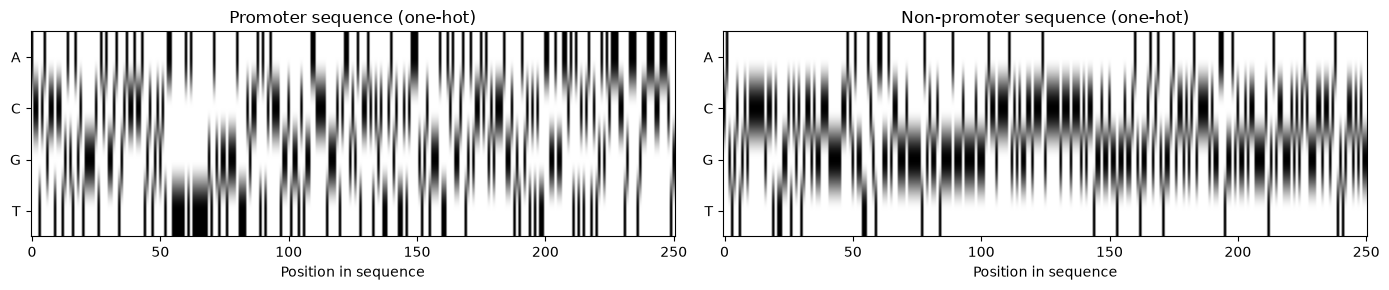

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
promoter_idx = np.where(y_train.ravel() == 1)[0][0]
nonpromoter_idx = np.where(y_train.ravel() == 0)[0][0]

for ax, idx, title in zip(axes, [promoter_idx, nonpromoter_idx], ['Promoter', 'Non-promoter']):
    ax.imshow(X_train[idx].T, aspect='auto', cmap='Greys')
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(['A', 'C', 'G', 'T'])
    ax.set_title(f'{title} sequence (one-hot)')
    ax.set_xlabel('Position in sequence')

plt.tight_layout()
plt.show()

### RNN Class

Implements a recurrent neural network from scratch, where the same weight matrices process the sequence one position at a time, carrying a hidden state forward across all 251 steps. **backward** implements backpropagation through time, propagating gradients backward across every timestep for those shared weights. Two techniques specifically address the difficulty of training on long sequences: orthogonal initialization of the recurrent weight matrix (preserves gradient magnitude across many repeated multiplications, rather than letting it shrink toward zero) and the Adam optimizer (adapts the step size per parameter, handling the small and uneven gradients typical of RNN training far better than a fixed learning rate).

In [ ]:
class RNN:
    def __init__(self, input_dim, hidden_dim, learning_rate=0.01):
        rng = np.random.RandomState(2)
        self.hidden_dim = hidden_dim
        self.Wxh = rng.randn(input_dim, hidden_dim) * np.sqrt(1 / input_dim)

        # orthogonal initialization: preserves gradient magnitude across many
        # repeated multiplications, counteracting vanishing gradients over long sequences
        A = rng.randn(hidden_dim, hidden_dim)
        Q, _ = np.linalg.qr(A)
        self.Whh = Q

        self.bh = np.zeros((1, hidden_dim))
        self.Why = rng.randn(hidden_dim, 1) * np.sqrt(1 / hidden_dim)
        self.by = np.zeros((1, 1))
        self.learning_rate = learning_rate

        # Adam optimizer state
        self.m = {k: np.zeros_like(v) for k, v in self._params().items()}
        self.v = {k: np.zeros_like(v) for k, v in self._params().items()}
        self.t = 0

    def _params(self):
        return {'Wxh': self.Wxh, 'Whh': self.Whh, 'bh': self.bh, 'Why': self.Why, 'by': self.by}

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        m, T, _ = X.shape
        h = np.zeros((m, self.hidden_dim))
        self.hs = {-1: h}
        self.xs = {}
        for t in range(T):
            x_t = X[:, t, :]
            h = np.tanh(x_t @ self.Wxh + h @ self.Whh + self.bh)
            self.xs[t] = x_t
            self.hs[t] = h
        self.T = T
        self.z = h @ self.Why + self.by
        self.y_pred = self.sigmoid(self.z)
        return self.y_pred

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        eps = 1e-8
        return -(1 / m) * np.sum(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

    def backward(self, X, y_true):
        m = X.shape[0]
        T = self.T

        dz = self.y_pred - y_true
        dWhy = (1 / m) * self.hs[T-1].T @ dz
        dby = (1 / m) * np.sum(dz, axis=0, keepdims=True)

        dh_next = dz @ self.Why.T
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh = np.zeros_like(self.bh)

        for t in reversed(range(T)):
            dtanh = (1 - self.hs[t]**2) * dh_next
            dWxh += (1 / m) * self.xs[t].T @ dtanh
            dWhh += (1 / m) * self.hs[t-1].T @ dtanh
            dbh += (1 / m) * np.sum(dtanh, axis=0, keepdims=True)
            dh_next = dtanh @ self.Whh.T

        grads = {'Wxh': dWxh, 'Whh': dWhh, 'bh': dbh, 'Why': dWhy, 'by': dby}
        for k in grads:
            np.clip(grads[k], -5, 5, out=grads[k])

        # Adam update
        self.t += 1
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        for k in grads:
            self.m[k] = beta1 * self.m[k] + (1 - beta1) * grads[k]
            self.v[k] = beta2 * self.v[k] + (1 - beta2) * (grads[k] ** 2)
            m_hat = self.m[k] / (1 - beta1 ** self.t)
            v_hat = self.v[k] / (1 - beta2 ** self.t)
            update = self.learning_rate * m_hat / (np.sqrt(v_hat) + eps)
            setattr(self, k, getattr(self, k) - update)

    def fit(self, X, y, epochs=100):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y_pred, y)
            losses.append(loss)
            self.backward(X, y)
            if epoch % 20 == 0:
                print(f"Epoch {epoch}: Loss {loss:.4f}")
        return losses

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

### Training Model

Prints the real class balance and baseline, then trains the from-scratch RNN for 100 epochs.

In [20]:
print(f"Majority-class baseline: {max(y_train.mean(), 1 - y_train.mean())*100:.2f}%")

rnn = RNN(input_dim=4, hidden_dim=16, learning_rate=0.01)
losses = rnn.fit(X_train, y_train, epochs=100)

train_predictions = rnn.predict(X_train)
test_predictions = rnn.predict(X_test)

train_accuracy = np.mean(train_predictions == y_train) * 100
test_accuracy = np.mean(test_predictions == y_test) * 100

print(f"Train accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy: {test_accuracy:.2f}%")

Majority-class baseline: 54.83%
Epoch 0: Loss 0.7428
Epoch 20: Loss 0.6131
Epoch 40: Loss 0.7225
Epoch 60: Loss 0.6659
Epoch 80: Loss 0.5466
Train accuracy: 75.03%
Test accuracy: 71.83%


Loss moves unevenly but downward (0.7428 → 0.5466 by epoch 80, with some real fluctuation along the way rather than a perfectly smooth descent). 

Final: **75.03% train accuracy, 71.83% test accuracy** which is meaningfully above the 54.83% baseline, confirming the network learned real sequence patterns associated with promoter regions rather than just guessing the majority class.

### Visualizing the Loss Curve

Plots the loss value recorded at every one of the 100 training epochs.

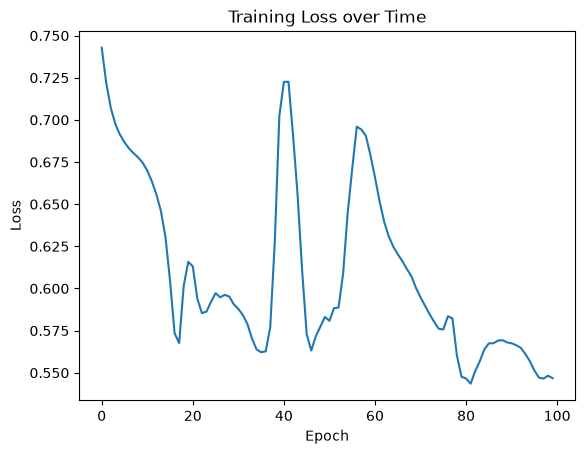

In [21]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.show()

Shows a real, somewhat noisy downward trend rather than a smoother curve. Which is expected here, since Adam's adaptive per-parameter steps combined with a genuinely harder long-sequence learning problem produce a bumpier trajectory than plain gradient descent on simpler tasks.

### PyTorch Validation

Fits an equivalent PyTorch RNN — same architecture, same orthogonal initialization on the recurrent weights, same Adam optimizer and learning rate, same gradient clipping, same 100-epoch budget, as an independent correctness check.

In [22]:
import torch
import torch.nn as nn

torch.manual_seed(2)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

class TorchRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        nn.init.orthogonal_(self.rnn.weight_hh_l0)  # match the from-scratch orthogonal init
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        _, h_n = self.rnn(x)
        return self.sigmoid(self.fc(h_n.squeeze(0)))

torch_rnn = TorchRNN(input_dim=4, hidden_dim=16)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(torch_rnn.parameters(), lr=0.01)  # matches the from-scratch Adam

for epoch in range(100):
    optimizer.zero_grad()
    outputs = torch_rnn(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_value_(torch_rnn.parameters(), clip_value=5)
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

with torch.no_grad():
    torch_test_preds = (torch_rnn(X_test_tensor) >= 0.5).float()
    torch_test_accuracy = (torch_test_preds == y_test_tensor).float().mean().item() * 100

print(f"From scratch: {test_accuracy:.2f}%")
print(f"PyTorch:      {torch_test_accuracy:.2f}%")

Epoch 0: Loss 0.6919
Epoch 20: Loss 0.5893
Epoch 40: Loss 0.5320
Epoch 60: Loss 0.5865
Epoch 80: Loss 0.5902
From scratch: 71.83%
PyTorch:      72.67%


**71.83%** (from scratch) vs. **72.67%** (PyTorch)